# AeroFit Treadmill Business Case

## Problem statement
AeroFit wants to understand which customer segments buy each treadmill model so the business can improve product recommendation for new customers.

## Products in scope
- `KP281`: entry-level treadmill priced at `$1,500`
- `KP481`: mid-level treadmill priced at `$1,750`
- `KP781`: premium treadmill priced at `$2,500`

## Objectives
1. Perform descriptive analysis of the customer dataset.
2. Study how customer characteristics vary by product.
3. Build contingency tables and compute marginal and conditional probabilities.
4. Create customer profiles for each treadmill.
5. Give actionable business recommendations in simple language.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


In [2]:
df = pd.read_csv('aerofit_treadmill.txt')

for col in ['Product', 'Gender', 'MaritalStatus']:
    df[col] = df[col].astype('category')

# Create useful business segments for deeper profiling.
df['AgeGroup'] = pd.cut(df['Age'], bins=[17, 24, 30, 35, 40, 60], labels=['18-24', '25-30', '31-35', '36-40', '41+'])
df['IncomeGroup'] = pd.cut(df['Income'], bins=[0, 40000, 50000, 60000, 80000, 120000], labels=['<40K', '40K-50K', '50K-60K', '60K-80K', '80K+'])
df['MilesGroup'] = pd.cut(df['Miles'], bins=[0, 50, 100, 150, 400], labels=['<=50', '51-100', '101-150', '150+'])

df.head()


,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,AgeGroup,IncomeGroup,MilesGroup
0,KP281,18,Male,14,Single,3,4,29562,112,18-24,<40K,101-150
1,KP281,19,Male,15,Single,2,3,31836,75,18-24,<40K,51-100
2,KP281,19,Female,14,Partnered,4,3,30699,66,18-24,<40K,51-100
3,KP281,19,Male,12,Single,3,3,32973,85,18-24,<40K,51-100
4,KP281,20,Male,13,Partnered,4,2,35247,47,18-24,<40K,<=50


## 1. Dataset overview
This dataset contains customers who purchased a treadmill from AeroFit stores in the previous three months. The first step is to inspect size, structure, data types, and summary statistics.


In [3]:
print(f'Shape of dataset: {df.shape}')
print()
print('Data types:')
print(df.dtypes)
print()
print('Missing values:')
print(df.isna().sum())
print()
print('Duplicate rows:', df.duplicated().sum())


Shape of dataset: (180, 12)

Data types:
Product          category
Age                 int64
Gender           category
Education           int64
MaritalStatus    category
Usage               int64
Fitness             int64
Income              int64
Miles               int64
AgeGroup         category
IncomeGroup      category
MilesGroup       category
dtype: object

Missing values:
Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
AgeGroup         0
IncomeGroup      0
MilesGroup       0
dtype: int64

Duplicate rows: 0


In [4]:
summary = df.describe(include='all').transpose()
summary


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product,180,3,KP281,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,180.00,NaN,NaN,NaN,28.79,6.94,18.00,24.00,26.00,33.00,50.00
Gender,180,2,Male,104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,180.00,NaN,NaN,NaN,15.57,1.62,12.00,14.00,16.00,16.00,21.00
MaritalStatus,180,2,Partnered,107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Usage,180.00,NaN,NaN,NaN,3.46,1.08,2.00,3.00,3.00,4.00,7.00
Fitness,180.00,NaN,NaN,NaN,3.31,0.96,1.00,3.00,3.00,4.00,5.00
Income,180.00,NaN,NaN,NaN,"53,719.58","16,506.68","29,562.00","44,058.75","50,596.50","58,668.00","104,581.00"
Miles,180.00,NaN,NaN,NaN,103.19,51.86,21.00,66.00,94.00,114.75,360.00
AgeGroup,180,5,25-30,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Observations
- The dataset has `180` rows and `9` original variables.
- There are no missing values and no duplicate rows.
- `Product`, `Gender`, and `MaritalStatus` are categorical features.
- Derived variables such as `AgeGroup`, `IncomeGroup`, and `MilesGroup` help make the customer profile easier to explain in business terms.


## 2. Non-graphical analysis
We begin with frequency tables and summary measures before moving to charts.


In [5]:
product_mix = pd.DataFrame({
    'Count': df['Product'].value_counts(),
    'Share %': (df['Product'].value_counts(normalize=True) * 100).round(2)
})
product_mix


,Count,Share %
Product,,
KP281,80,44.44
KP481,60,33.33
KP781,40,22.22


In [6]:
categorical_columns = ['Product', 'Gender', 'MaritalStatus', 'AgeGroup', 'IncomeGroup', 'MilesGroup']
for col in categorical_columns:
    print()
    print(f'Value counts for {col}:')
    display(df[col].value_counts(dropna=False).to_frame('Count'))



Value counts for Product:


,Count
Product,
KP281,80
KP481,60
KP781,40



Value counts for Gender:


,Count
Gender,
Male,104
Female,76



Value counts for MaritalStatus:


...

,Count
AgeGroup,
25-30,66
18-24,54
31-35,32
36-40,16
41+,12



Value counts for IncomeGroup:


,Count
IncomeGroup,
50K-60K,55
40K-50K,51
<40K,32
60K-80K,23
80K+,19



Value counts for MilesGroup:


,Count
MilesGroup,
51-100,97
101-150,38
150+,28
<=50,17


In [7]:
numeric_summary = df[['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']].agg(['mean', 'median', 'std', 'min', 'max']).T
numeric_summary


,mean,median,std,min,max
Age,28.79,26.00,6.94,18.00,50.00
Education,15.57,16.00,1.62,12.00,21.00
Usage,3.46,3.00,1.08,2.00,7.00
Fitness,3.31,3.00,0.96,1.00,5.00
Income,"53,719.58","50,596.50","16,506.68","29,562.00","104,581.00"
Miles,103.19,94.00,51.86,21.00,360.00


### Non-graphical insights
- `KP281` is the most sold treadmill with `44.44%` share.
- `KP481` contributes `33.33%`, while `KP781` contributes `22.22%`.
- Overall customer mix is somewhat male-heavy.
- Most customers fall in the `40K-60K` income range and in the `25-30` or `18-24` age bands.
- The large spread in `Income` and `Miles` suggests that the three products likely target very different intensity and affordability segments.


## 3. Univariate analysis
This section studies the standalone distribution of each variable.


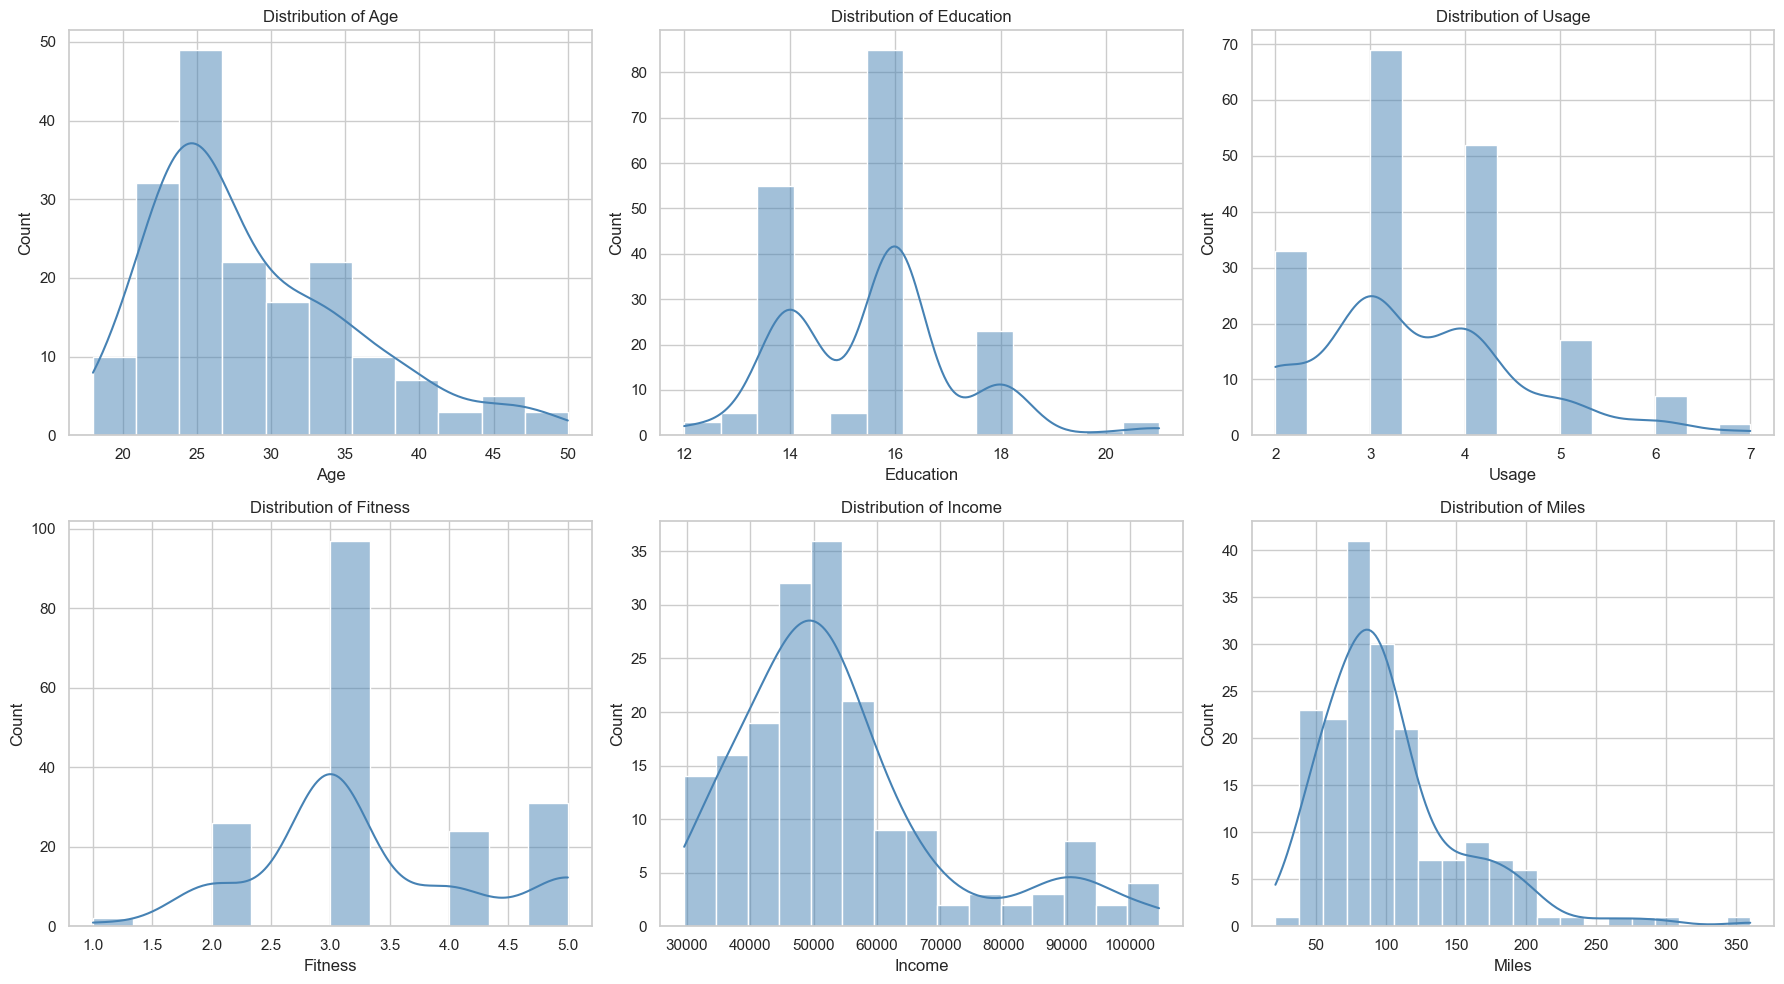

In [8]:
num_cols = ['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


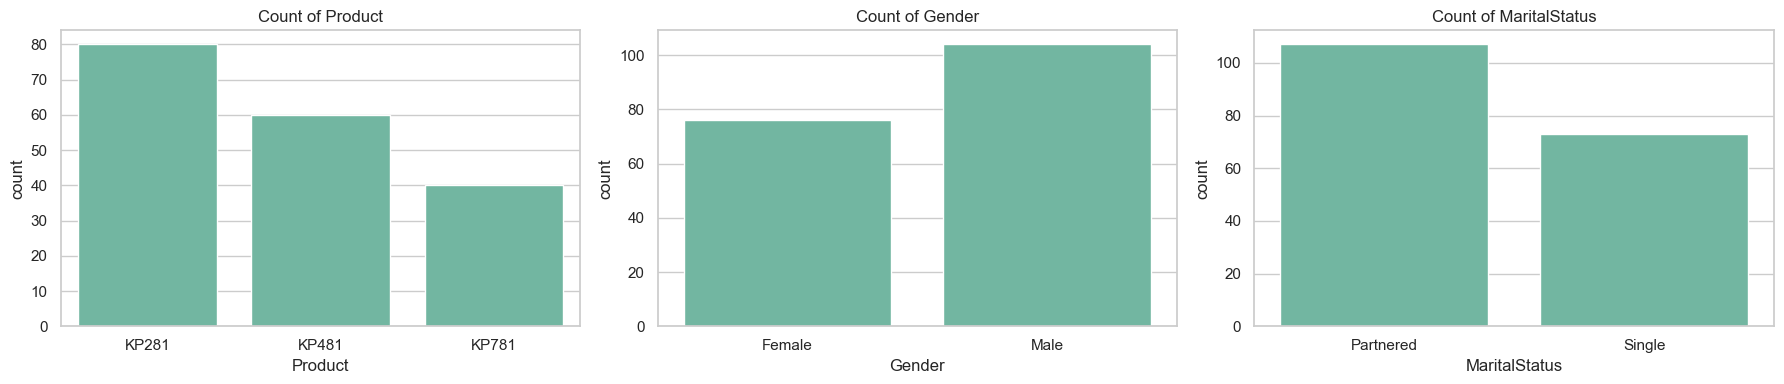

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, ['Product', 'Gender', 'MaritalStatus']):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f'Count of {col}')
plt.tight_layout()
plt.show()


### Univariate insights
- `Age` is centered around the late 20s, with relatively few customers above 40.
- `Education` is concentrated near `14` to `18` years.
- `Usage`, `Fitness`, and `Miles` are positively skewed because a smaller group of advanced buyers reports much heavier treadmill usage.
- `Income` also has right skew, which hints that premium buyers may be present in the sample.


## 4. Outlier detection
Outliers are reviewed using boxplots and the IQR method. In this case, outliers are not automatically treated as bad data because premium treadmill buyers can genuinely have very high income, usage, and miles.


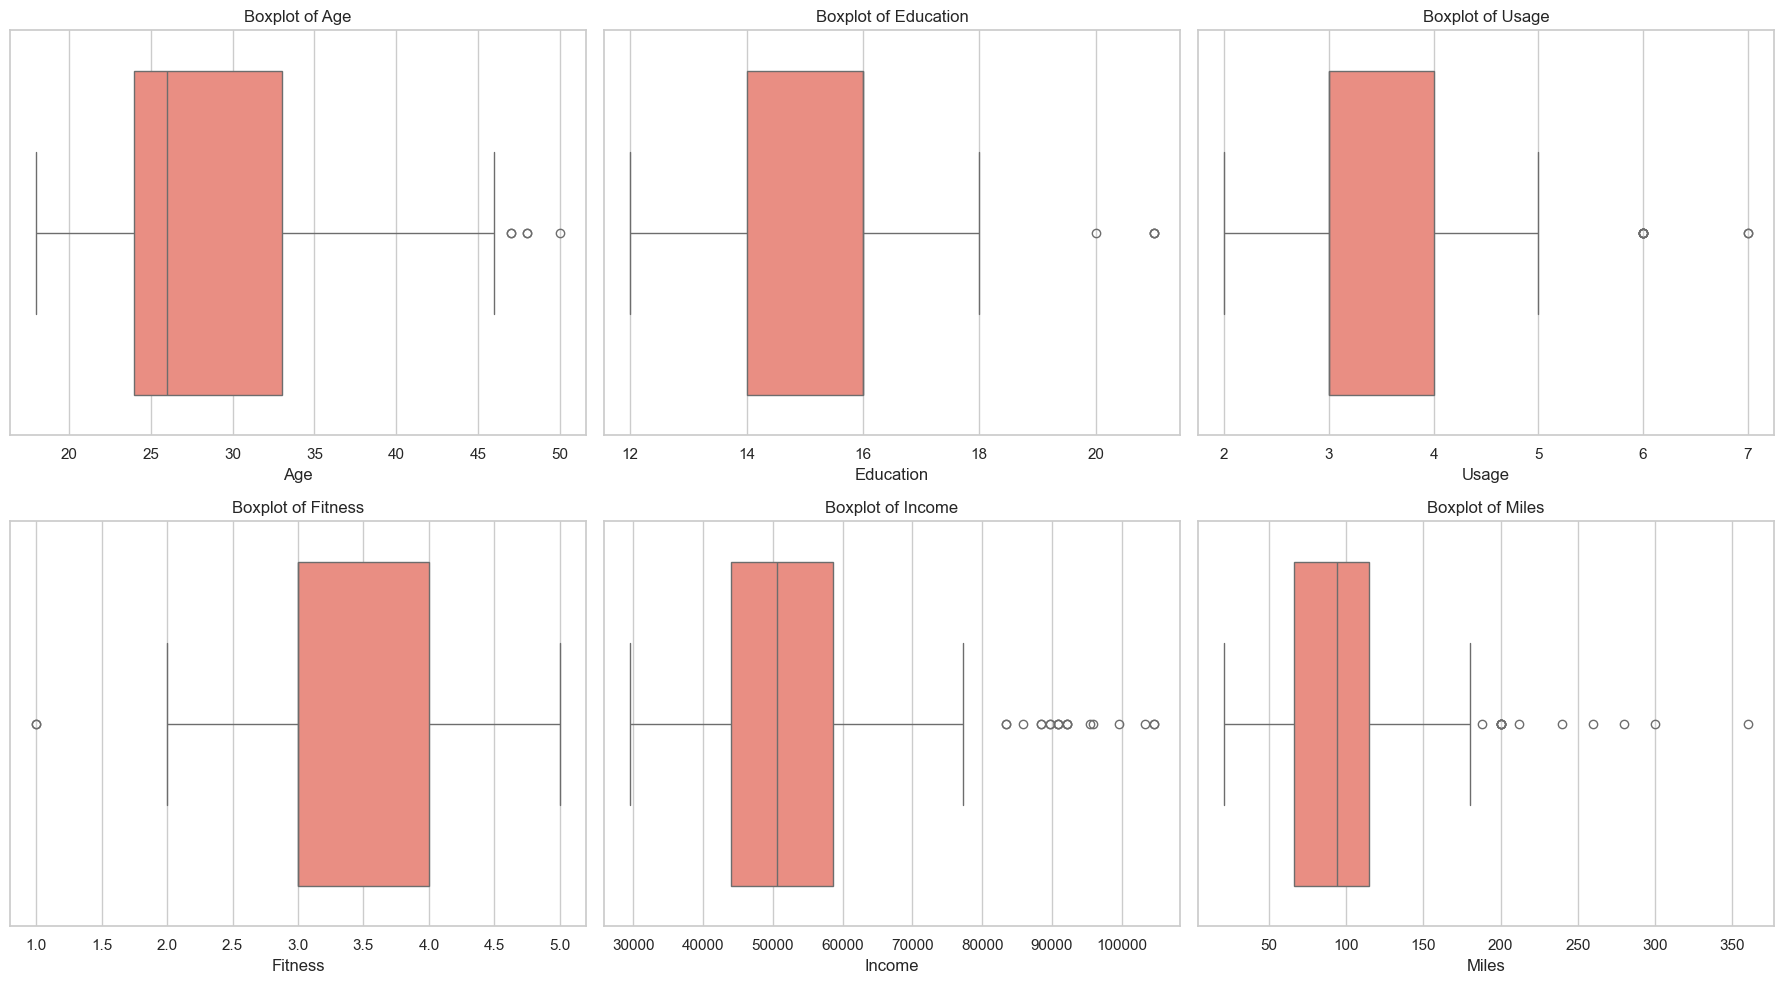

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(data=df, x=col, ax=ax, color='salmon')
    ax.set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


In [11]:
outlier_report = []
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    flagged = df[(df[col] < lower) | (df[col] > upper)]
    outlier_report.append({
        'Feature': col,
        'Q1': q1,
        'Q3': q3,
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Outlier Count': len(flagged),
        'KP281 Outliers': (flagged['Product'] == 'KP281').sum(),
        'KP481 Outliers': (flagged['Product'] == 'KP481').sum(),
        'KP781 Outliers': (flagged['Product'] == 'KP781').sum()
    })

outlier_report = pd.DataFrame(outlier_report)
outlier_report


,Feature,Q1,Q3,Lower Bound,Upper Bound,Outlier Count,KP281 Outliers,KP481 Outliers,KP781 Outliers
0,Age,24.00,33.00,10.50,46.50,5,2,1,2
1,Education,14.00,16.00,11.00,19.00,4,0,0,4
2,Usage,3.00,4.00,1.50,5.50,9,0,0,9
3,Fitness,3.00,4.00,1.50,5.50,2,1,1,0
4,Income,"44,058.75","58,668.00","22,144.88","80,581.88",19,0,0,19
5,Miles,66.00,114.75,-7.12,187.88,13,1,1,11


### Outlier insights
- Most `Income`, `Usage`, `Education`, and `Miles` outliers belong to `KP781` buyers.
- That pattern supports the business story that `KP781` attracts a premium, high-performance segment.
- These observations should be retained, not removed, because they are meaningful for targeting and recommendation.


## 5. Product-wise descriptive profiling
Since the business question is about product recommendation, the most important view is how each product differs across customer characteristics.


In [12]:
product_summary = df.groupby('Product')[['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
product_summary


Age                     Education                     Usage         \
         mean median  std min max      mean median  std min max  mean median   
Product                                                                        
KP281   28.55  26.00 7.22  18  50     15.04  16.00 1.22  12  18  3.09   3.00   
KP481   28.90  26.00 6.65  19  48     15.12  16.00 1.22  12  18  3.07   3.00   
KP781   29.10  27.00 6.97  22  48     17.32  18.00 1.64  14  21  4.78   5.00   

                     Fitness                        Income            \
         std min max    mean median  std min max      mean    median   
Product                                                                
KP281   0.78   2   5    2.96   3.00 0.66   1   5 46,418.02 46,617.00   
KP481   0.80   2   5    2.90   3.00 0.63   1   4 48,973.65 49,459.50   
KP781   0.95   3   7    4.62   5.00 0.67   3   5 75,441.58 76,568.50   

                                  Miles                        
              std    min     max   mean median   std min  max  
Product                                                        
KP281    9,075.78  29562   68220  82.79  85.00 28.87  38  188  
KP481    8,653.99  31836   67083  87.93  85.00 33.26  21  212  
KP781   18,505.84  48556  104581 166.90 160.00 60.07  80  360

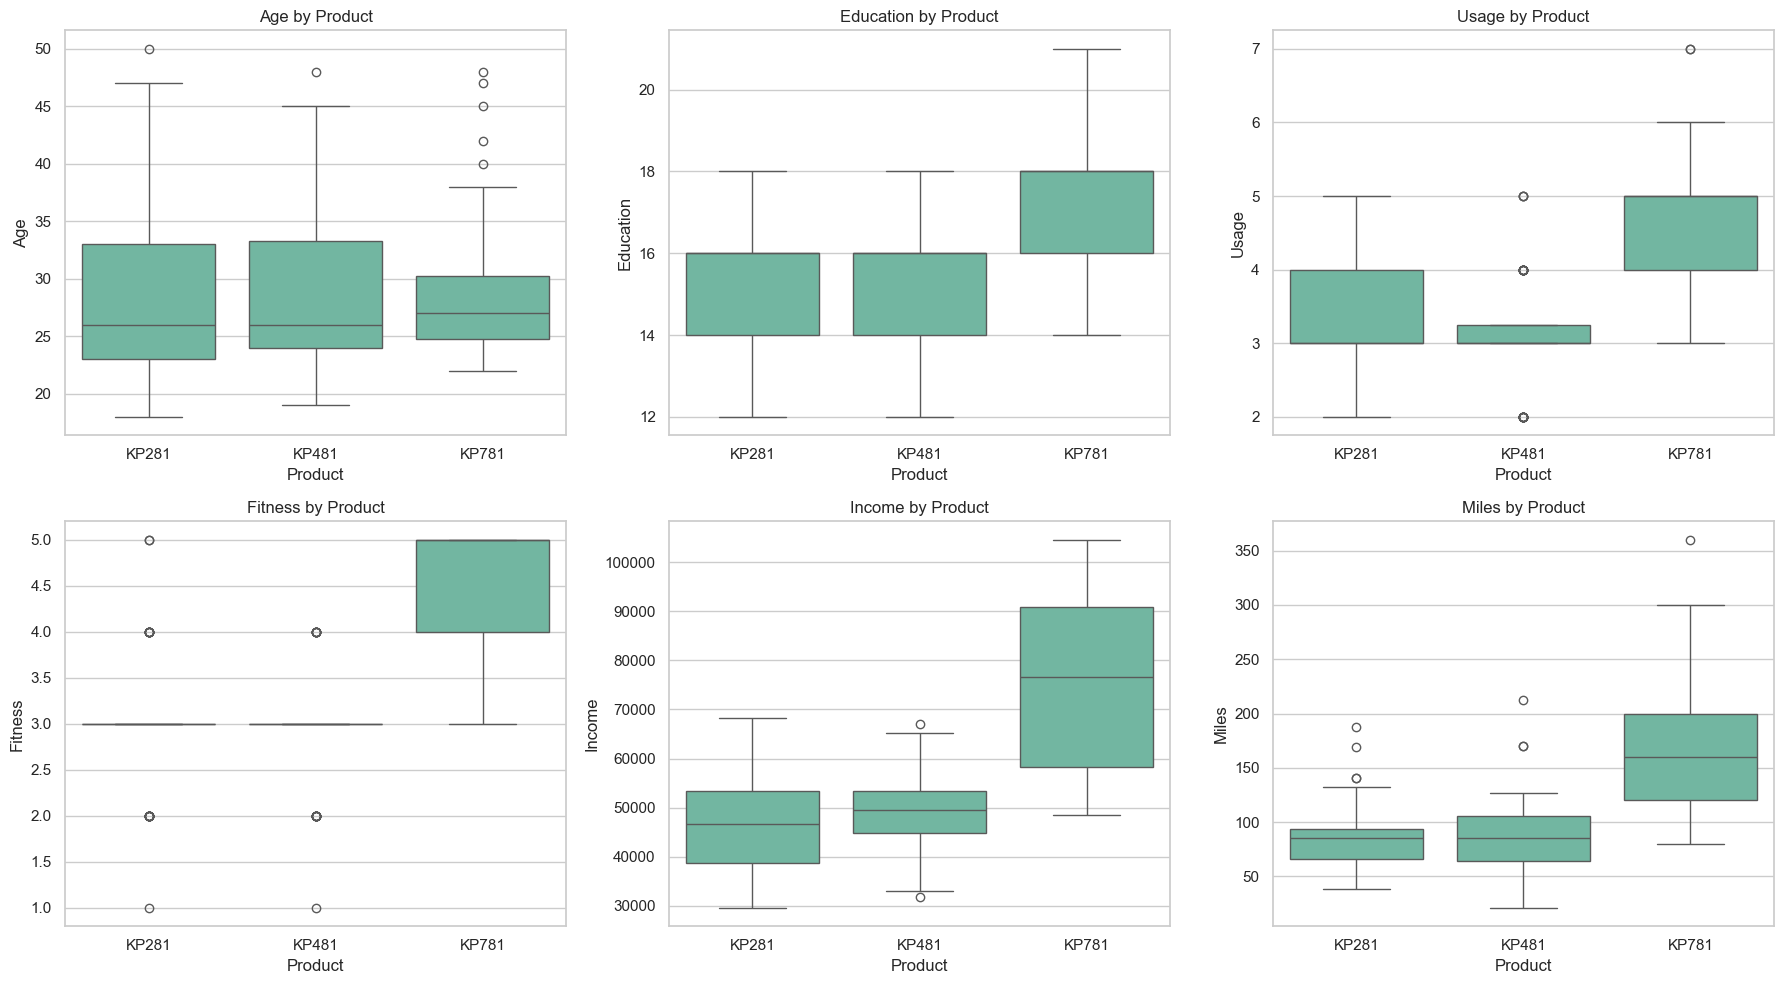

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(data=df, x='Product', y=col, ax=ax)
    ax.set_title(f'{col} by Product')
plt.tight_layout()
plt.show()


### Product-wise insights
- `KP281` and `KP481` buyers are similar in age, usage, fitness, and miles.
- `KP481` buyers are slightly better off than `KP281` buyers, but the difference is not dramatic.
- `KP781` buyers stand out clearly with much higher education, income, weekly usage, self-rated fitness, and planned miles.
- `Age` alone is not a strong separator between products. Workout intensity and paying capacity are much stronger signals.


## 6. Bivariate analysis for customer segments
We now compare product choice across gender, marital status, age groups, income groups, and workout-intensity segments.


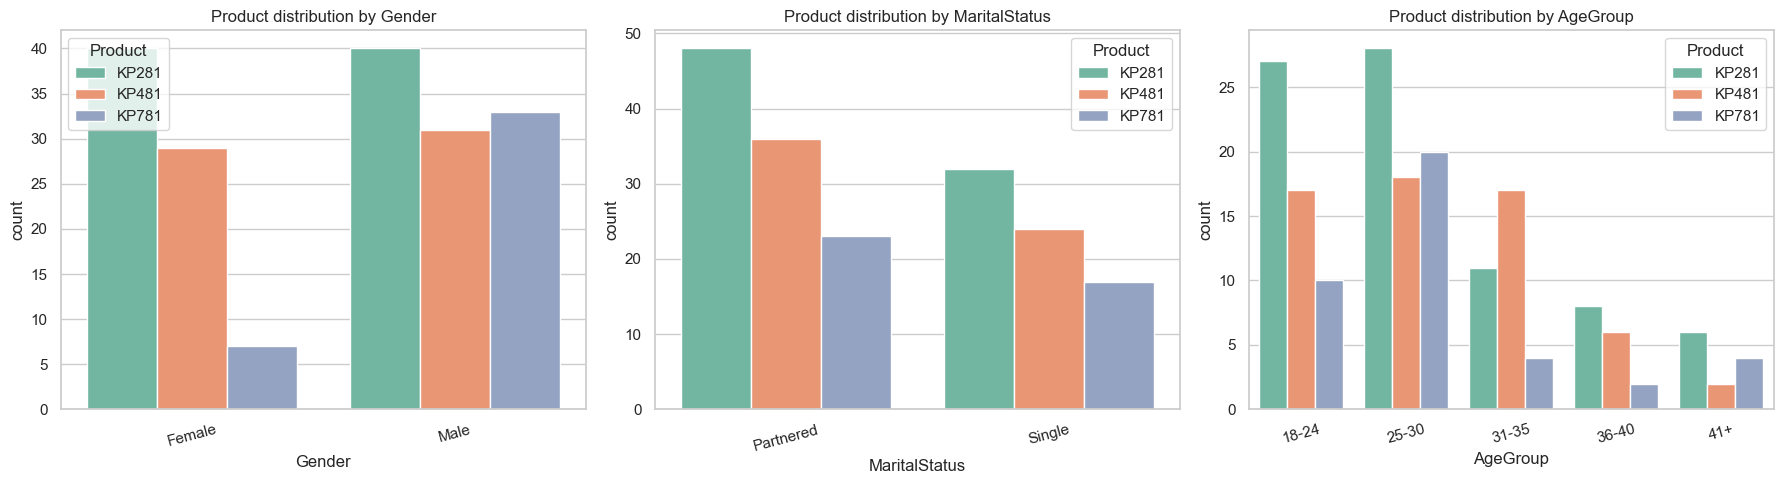

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
segment_cols = ['Gender', 'MaritalStatus', 'AgeGroup']
for ax, col in zip(axes, segment_cols):
    sns.countplot(data=df, x=col, hue='Product', ax=ax)
    ax.set_title(f'Product distribution by {col}')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


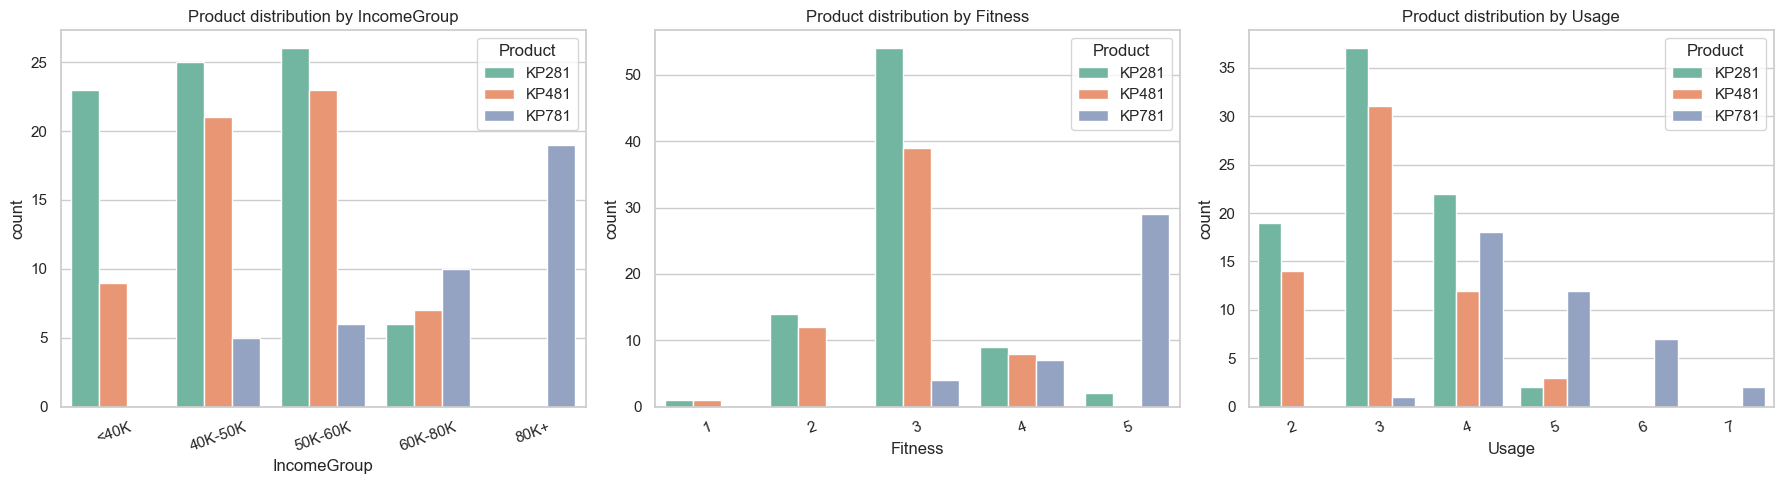

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
segment_cols = ['IncomeGroup', 'Fitness', 'Usage']
for ax, col in zip(axes, segment_cols):
    sns.countplot(data=df, x=col, hue='Product', ax=ax)
    ax.set_title(f'Product distribution by {col}')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


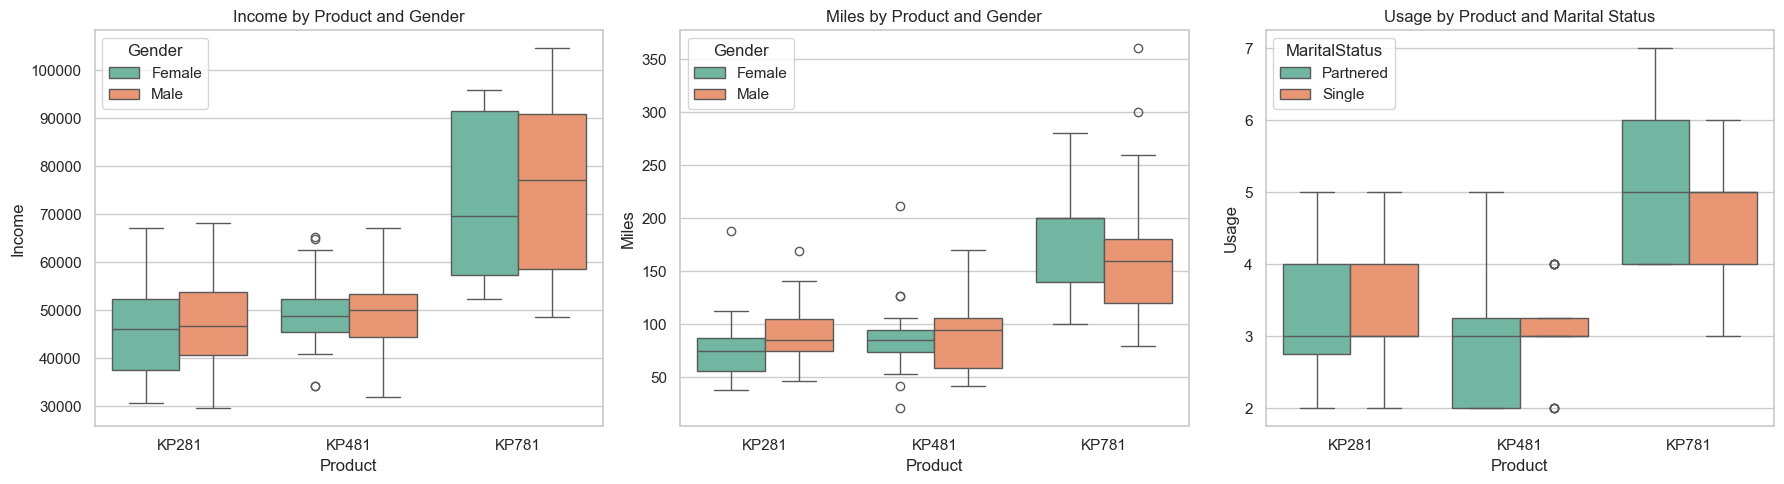

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df, x='Product', y='Income', hue='Gender', ax=axes[0])
axes[0].set_title('Income by Product and Gender')

sns.boxplot(data=df, x='Product', y='Miles', hue='Gender', ax=axes[1])
axes[1].set_title('Miles by Product and Gender')

sns.boxplot(data=df, x='Product', y='Usage', hue='MaritalStatus', ax=axes[2])
axes[2].set_title('Usage by Product and Marital Status')

plt.tight_layout()
plt.show()


### Bivariate insights
- `MaritalStatus` does not show a meaningful separation across products.
- `Gender` matters more for `KP781`; the product is heavily male-dominated in this sample.
- `IncomeGroup`, `Usage`, and `Fitness` are much stronger separators than demographic attributes.
- Customers with `Fitness = 5`, `Usage >= 5`, or `Miles > 150` are concentrated in the premium treadmill segment.


## 7. Correlation analysis
This section checks whether numerical variables move together.


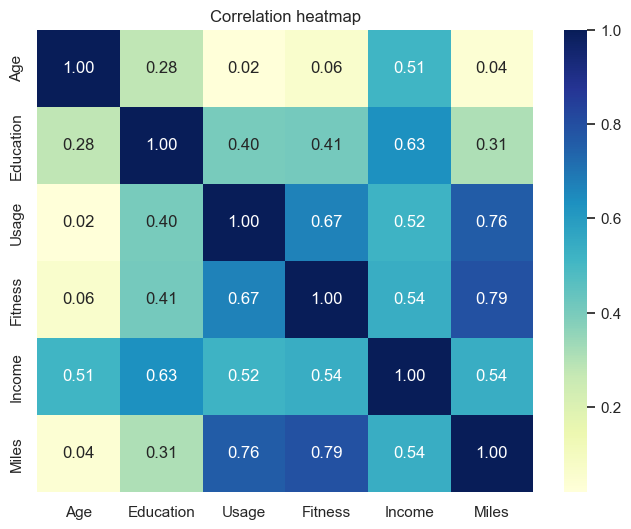

,Age,Education,Usage,Fitness,Income,Miles
Age,1.00,0.28,0.02,0.06,0.51,0.04
Education,0.28,1.00,0.40,0.41,0.63,0.31
Usage,0.02,0.40,1.00,0.67,0.52,0.76
Fitness,0.06,0.41,0.67,1.00,0.54,0.79
Income,0.51,0.63,0.52,0.54,1.00,0.54
Miles,0.04,0.31,0.76,0.79,0.54,1.00


In [17]:
corr = df[['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']].corr().round(2)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlation heatmap')
plt.show()

corr


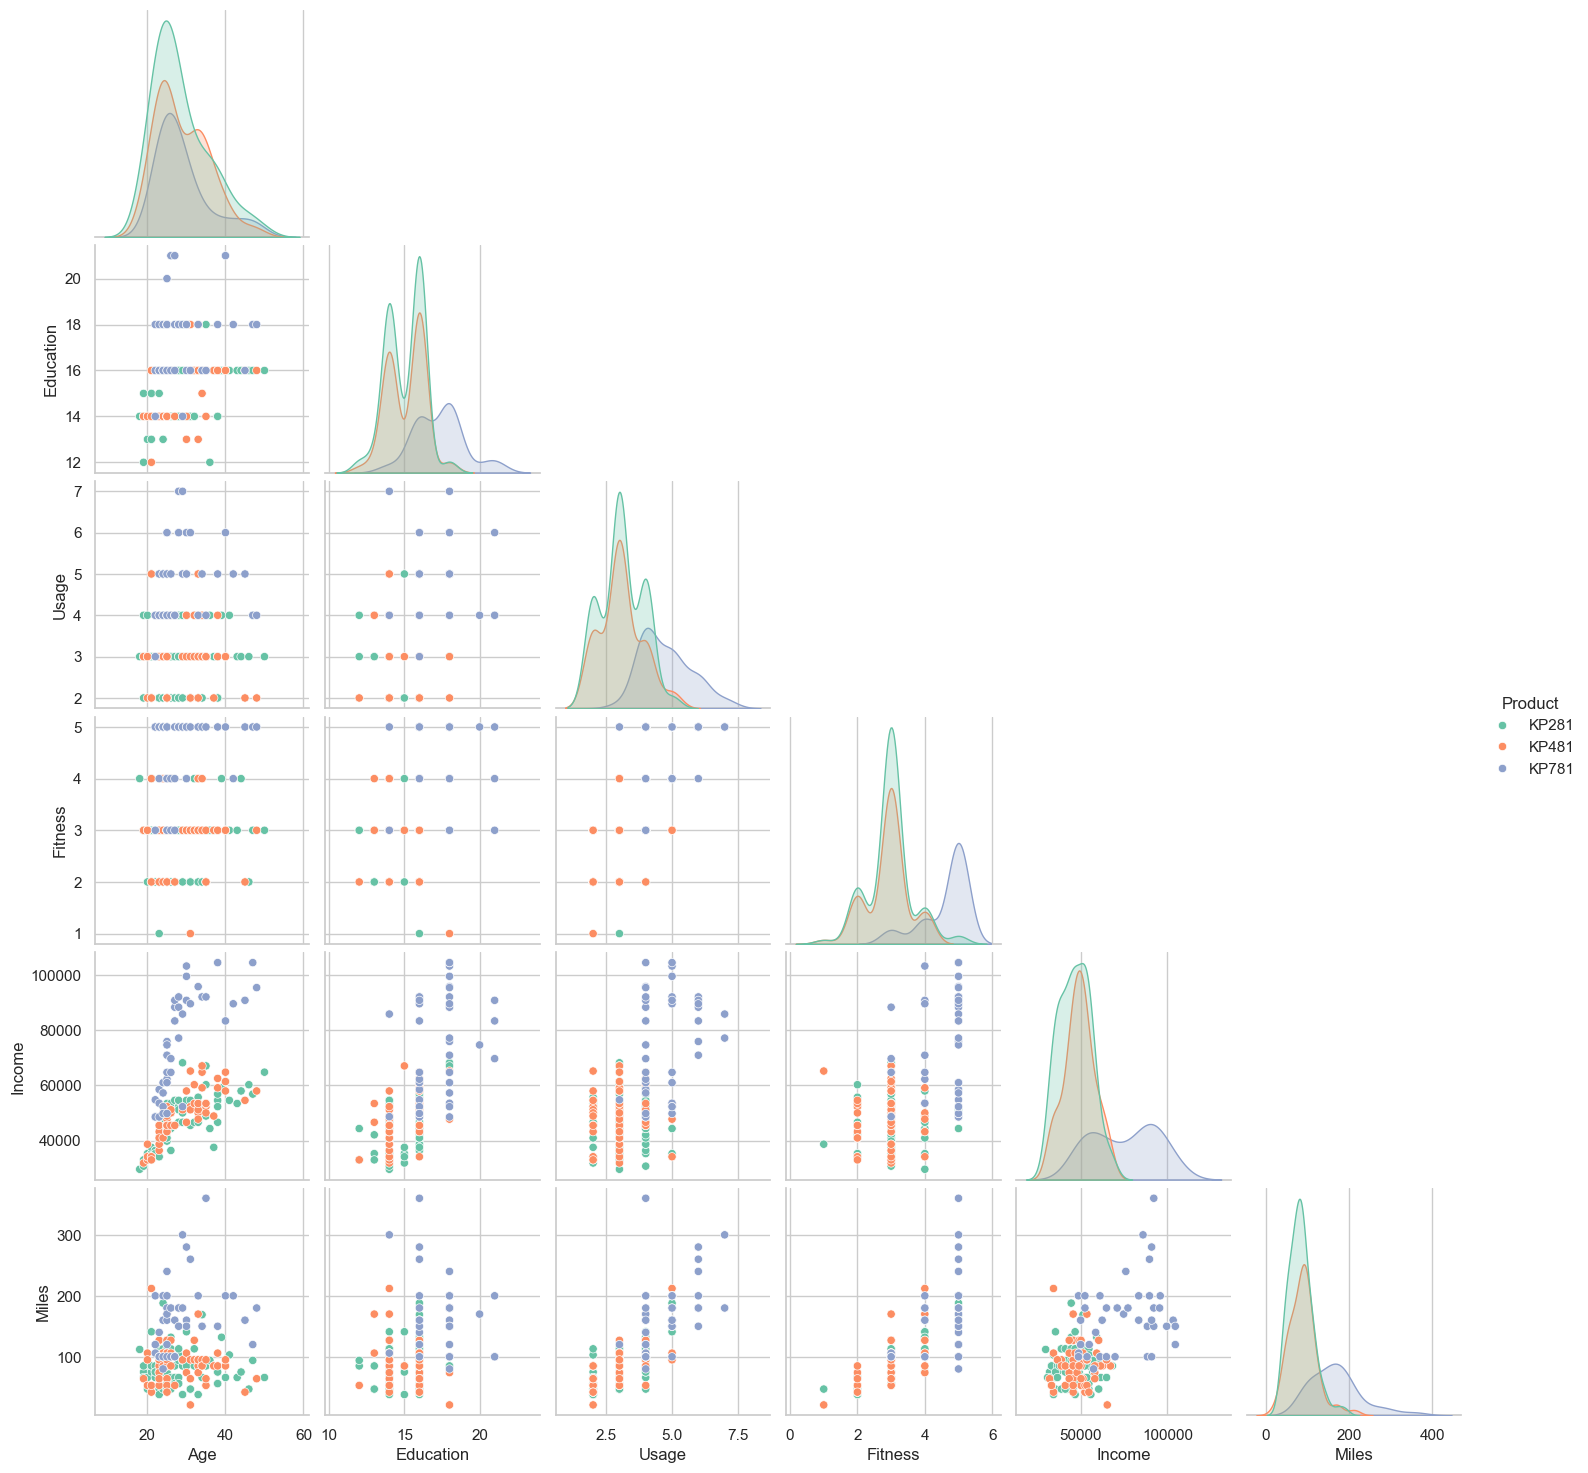

In [18]:
sns.pairplot(df[['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles', 'Product']], hue='Product', corner=True)
plt.show()


### Correlation insights
- `Miles` has strong positive correlation with both `Usage` and `Fitness`.
- `Income` is moderately correlated with `Education`, `Usage`, `Fitness`, and `Miles`.
- `Age` has weaker correlation with workout variables, so it should not be used as the primary recommendation driver.


## 8. Contingency tables and probability analysis
This is the core business section. We calculate marginal probabilities and conditional probabilities to understand product likelihood for each customer segment.


In [19]:
marginal_probability = pd.DataFrame({
    'Count': df['Product'].value_counts(),
    'Marginal Probability': df['Product'].value_counts(normalize=True).round(4),
    'Marginal Probability %': (df['Product'].value_counts(normalize=True) * 100).round(2)
})
marginal_probability


,Count,Marginal Probability,Marginal Probability %
Product,,,
KP281,80,0.44,44.44
KP481,60,0.33,33.33
KP781,40,0.22,22.22


In [20]:
def probability_tables(segment):
    counts = pd.crosstab(df[segment], df['Product'])
    row_prob = pd.crosstab(df[segment], df['Product'], normalize='index').round(4)
    col_prob = pd.crosstab(df[segment], df['Product'], normalize='columns').round(4)
    return counts, row_prob, col_prob

for segment in ['Gender', 'MaritalStatus', 'AgeGroup', 'IncomeGroup', 'Fitness', 'Usage', 'MilesGroup']:
    print()
    print(f'===== {segment} vs Product =====')
    counts, row_prob, col_prob = probability_tables(segment)
    print('Counts')
    display(counts)
    print('P(Product | Segment)')
    display(row_prob)
    print('P(Segment | Product)')
    display(col_prob)



===== Gender vs Product =====
Counts


Product,KP281,KP481,KP781
Gender,,,
Female,40,29,7
Male,40,31,33


P(Product | Segment)


Product,KP281,KP481,KP781
Gender,,,
Female,0.53,0.38,0.09
Male,0.38,0.30,0.32


P(Segment | Product)


...

Product,KP281,KP481,KP781
MilesGroup,,,
<=50,12,5,0
51-100,50,39,8
101-150,16,13,9
150+,2,3,23


P(Product | Segment)


Product,KP281,KP481,KP781
MilesGroup,,,
<=50,0.71,0.29,0.00
51-100,0.52,0.40,0.08
101-150,0.42,0.34,0.24
150+,0.07,0.11,0.82


P(Segment | Product)


Product,KP281,KP481,KP781
MilesGroup,,,
<=50,0.15,0.08,0.00
51-100,0.62,0.65,0.20
101-150,0.20,0.22,0.23
150+,0.03,0.05,0.57


In [21]:
probability_examples = pd.DataFrame({
    'Question': [
        'What is the probability of purchasing KP281?',
        'What is the probability of purchasing KP481?',
        'What is the probability of purchasing KP781?',
        'What is the probability that a customer is Male and bought KP781?',
        'What is the probability of buying KP781 given the customer is Male?',
        'What is the probability of buying KP781 given the customer is Female?',
        'What is the probability of buying KP781 given Fitness = 5?',
        'What is the probability of buying KP781 given Usage >= 5?',
        'What is the probability of buying KP781 given Income >= 80K?',
        'What is the probability of buying KP281 given Income < 40K?',
        'What is the probability of buying KP781 given Miles > 150?'
    ],
    'Probability': [
        (df['Product'] == 'KP281').mean(),
        (df['Product'] == 'KP481').mean(),
        (df['Product'] == 'KP781').mean(),
        ((df['Gender'] == 'Male') & (df['Product'] == 'KP781')).mean(),
        (df.loc[df['Gender'] == 'Male', 'Product'] == 'KP781').mean(),
        (df.loc[df['Gender'] == 'Female', 'Product'] == 'KP781').mean(),
        (df.loc[df['Fitness'] == 5, 'Product'] == 'KP781').mean(),
        (df.loc[df['Usage'] >= 5, 'Product'] == 'KP781').mean(),
        (df.loc[df['Income'] >= 80000, 'Product'] == 'KP781').mean(),
        (df.loc[df['Income'] < 40000, 'Product'] == 'KP281').mean(),
        (df.loc[df['Miles'] > 150, 'Product'] == 'KP781').mean()
    ]
})
probability_examples['Probability %'] = (probability_examples['Probability'] * 100).round(2)
probability_examples


,Question,Probability,Probability %
0,What is the probability of purchasing KP281?,0.44,44.44
1,What is the probability of purchasing KP481?,0.33,33.33
2,What is the probability of purchasing KP781?,0.22,22.22
3,What is the probability that a customer is Mal...,0.18,18.33
4,What is the probability of buying KP781 given ...,0.32,31.73
5,What is the probability of buying KP781 given ...,0.09,9.21
6,What is the probability of buying KP781 given ...,0.94,93.55
7,What is the probability of buying KP781 given ...,0.81,80.77
8,What is the probability of buying KP781 given ...,1.00,100.00
9,What is the probability of buying KP281 given ...,0.72,71.88


### Probability insights
- `P(KP281) = 44.44%`, `P(KP481) = 33.33%`, and `P(KP781) = 22.22%`.
- `P(Male and KP781) = 18.33%`.
- `P(KP781 | Male) = 31.73%`, but `P(KP781 | Female) = 9.21%`.
- `P(KP781 | Fitness = 5) = 93.55%`, which is one of the strongest segment signals in the dataset.
- `P(KP781 | Usage >= 5)` is also very high, showing that frequent users strongly prefer the premium model.
- Customers with income above `80K` all purchased `KP781` in this sample.
- Customers with income below `40K` overwhelmingly prefer `KP281`.


## 9. Customer profiling
The product profiles below convert the analysis into easy-to-use customer summaries for the sales team.


In [22]:
profile_table = pd.DataFrame({
    'Product': ['KP281', 'KP481', 'KP781'],
    'Median Age': [df.loc[df['Product']=='KP281', 'Age'].median(), df.loc[df['Product']=='KP481', 'Age'].median(), df.loc[df['Product']=='KP781', 'Age'].median()],
    'Median Education': [df.loc[df['Product']=='KP281', 'Education'].median(), df.loc[df['Product']=='KP481', 'Education'].median(), df.loc[df['Product']=='KP781', 'Education'].median()],
    'Median Usage/week': [df.loc[df['Product']=='KP281', 'Usage'].median(), df.loc[df['Product']=='KP481', 'Usage'].median(), df.loc[df['Product']=='KP781', 'Usage'].median()],
    'Median Fitness': [df.loc[df['Product']=='KP281', 'Fitness'].median(), df.loc[df['Product']=='KP481', 'Fitness'].median(), df.loc[df['Product']=='KP781', 'Fitness'].median()],
    'Median Income': [df.loc[df['Product']=='KP281', 'Income'].median(), df.loc[df['Product']=='KP481', 'Income'].median(), df.loc[df['Product']=='KP781', 'Income'].median()],
    'Median Miles/week': [df.loc[df['Product']=='KP281', 'Miles'].median(), df.loc[df['Product']=='KP481', 'Miles'].median(), df.loc[df['Product']=='KP781', 'Miles'].median()]
})
profile_table


,Product,Median Age,Median Education,Median Usage/week,Median Fitness,Median Income,Median Miles/week
0,KP281,26.00,16.00,3.00,3.00,"46,617.00",85.00
1,KP481,26.00,16.00,3.00,3.00,"49,459.50",85.00
2,KP781,27.00,18.00,5.00,5.00,"76,568.50",160.00


### Customer profiles
- `KP281`: Entry-level buyers. They usually have lower income, moderate fitness, and moderate planned weekly usage. This model fits first-time buyers and budget-conscious customers.
- `KP481`: Intermediate buyers. They look similar to `KP281` buyers but are slightly more active and slightly more affluent. This product fits customers who want a better treadmill without moving to the premium tier.
- `KP781`: Premium performance buyers. They have much higher income, stronger self-rated fitness, higher weekly usage, and much higher planned miles. This is clearly a specialist product for serious runners and heavy users.


## 10. Final business recommendations

### Key business insights
- Product choice is driven much more by `Income`, `Fitness`, `Usage`, and `Miles` than by `Age` or `MaritalStatus`.
- `KP781` is not a mass-market product. It is a premium treadmill bought by affluent, workout-intensive users.
- `KP281` and `KP481` serve the larger mainstream market, with `KP481` acting as an upgrade path from the entry model.
- Marital status has very little practical value for recommendation.

### Recommendations
1. Use `budget`, `fitness level`, `weekly usage`, and `planned weekly miles` as the main recommendation questions for new customers.
2. Recommend `KP281` to customers with lower budgets, lower planned miles, and moderate workout intensity.
3. Recommend `KP481` to customers who are regular runners but not extreme users and who want better performance than the entry model.
4. Recommend `KP781` only when the customer shows clear premium signals such as high income, high fitness, high weekly usage, or high planned mileage.
5. Build a simple in-store recommendation rule: if a customer reports `Fitness = 5`, `Usage >= 5`, or very high weekly miles, directly guide the conversation toward `KP781`.
6. Market `KP781` through premium messaging instead of broad generic advertising.
7. Avoid segmenting campaigns based heavily on marital status because it does not meaningfully change purchase behavior in this dataset.

### Conclusion
AeroFit should center its recommendation strategy on workout intensity and affordability. The strongest premium signal in this dataset is not age; it is a combination of income, usage, fitness, and miles. That makes the product ladder clear: `KP281` for entry-level users, `KP481` for regular runners, and `KP781` for serious performance-focused customers.
